In [1]:
from pathlib import Path
import sys
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

sys.path.append("../")
from src.data_processing.feature_selection import select_uncorrelated_features
from src.plots.maps import russia_plots
from src.static.cluster_tools import plot_silhouette_range
from src.utils.logger import setup_logger

logger = setup_logger("hydro_atlas_converter", logger_name="../logs/hydro_atlas_converter.log")

gpd.options.io_engine = "pyogrio"

warnings.simplefilter(action="ignore", category=FutureWarning)

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]


In [94]:
proper_dis = list({i.stem for i in Path("../data/HydroFiles/Discharge").rglob("decent/*.csv")})
proper_lvl = list(
    {i.stem for i in Path("../data/HydroFiles/Levels").rglob("*decent/*.csv") if "shifted" not in str(i)}
)


ws = gpd.read_file("../data/Geometry/WatershedGeomCAMELS.gpkg")
ws.set_index("gauge_id", inplace=True)
# ws = ws.loc[[ind for ind in ws.index if (ind in proper_dis)], :]
gauge = gpd.read_file("../data/Geometry/GaugeGeomCAMELS.gpkg")
gauge.set_index("gauge_id", inplace=True)
# gauge = gauge.loc[[ind for ind in gauge.index if (ind in proper_dis)], :]

basemap_data = gpd.read_file("../data/Geometry/basemap.gpkg")

### Size distribution of catchment areas

In [95]:
def lim_definer(area: float):
    lim_1, lim_2, lim_3, lim_4, lim_5 = 100, 2000, 10000, 50000, 200000

    if area < lim_1:
        return "a) < 100 $km^2$"
    elif (area >= lim_1) & (area <= lim_2):
        return "b) 100 $km^2$ - 2 000 $km^2$"
    elif (area > lim_2) & (area <= lim_3):
        return "c) 2 000 $km^2$ - 10 000 $km^2$"
    elif (area > lim_3) & (area <= lim_4):
        return "d) 10 000 $km^2$ - 50 000 $km^2$"
    elif (area > lim_4) & (area <= lim_5):
        return "e) 50 000 $km^2$ - 200 000 $km^2$"
    else:
        return "f) > 200 000 $km^2$"


ws["size"] = ws.loc[:, "area"].apply(lambda x: lim_definer(x))
ws["size"] = pd.Categorical(
    ws["size"],
    [
        "a) < 100 $km^2$",
        "b) 100 $km^2$ - 2 000 $km^2$",
        "c) 2 000 $km^2$ - 10 000 $km^2$",
        "d) 10 000 $km^2$ - 50 000 $km^2$",
        "e) 50 000 $km^2$ - 200 000 $km^2$",
        "f) > 200 000 $km^2$",
    ],
)


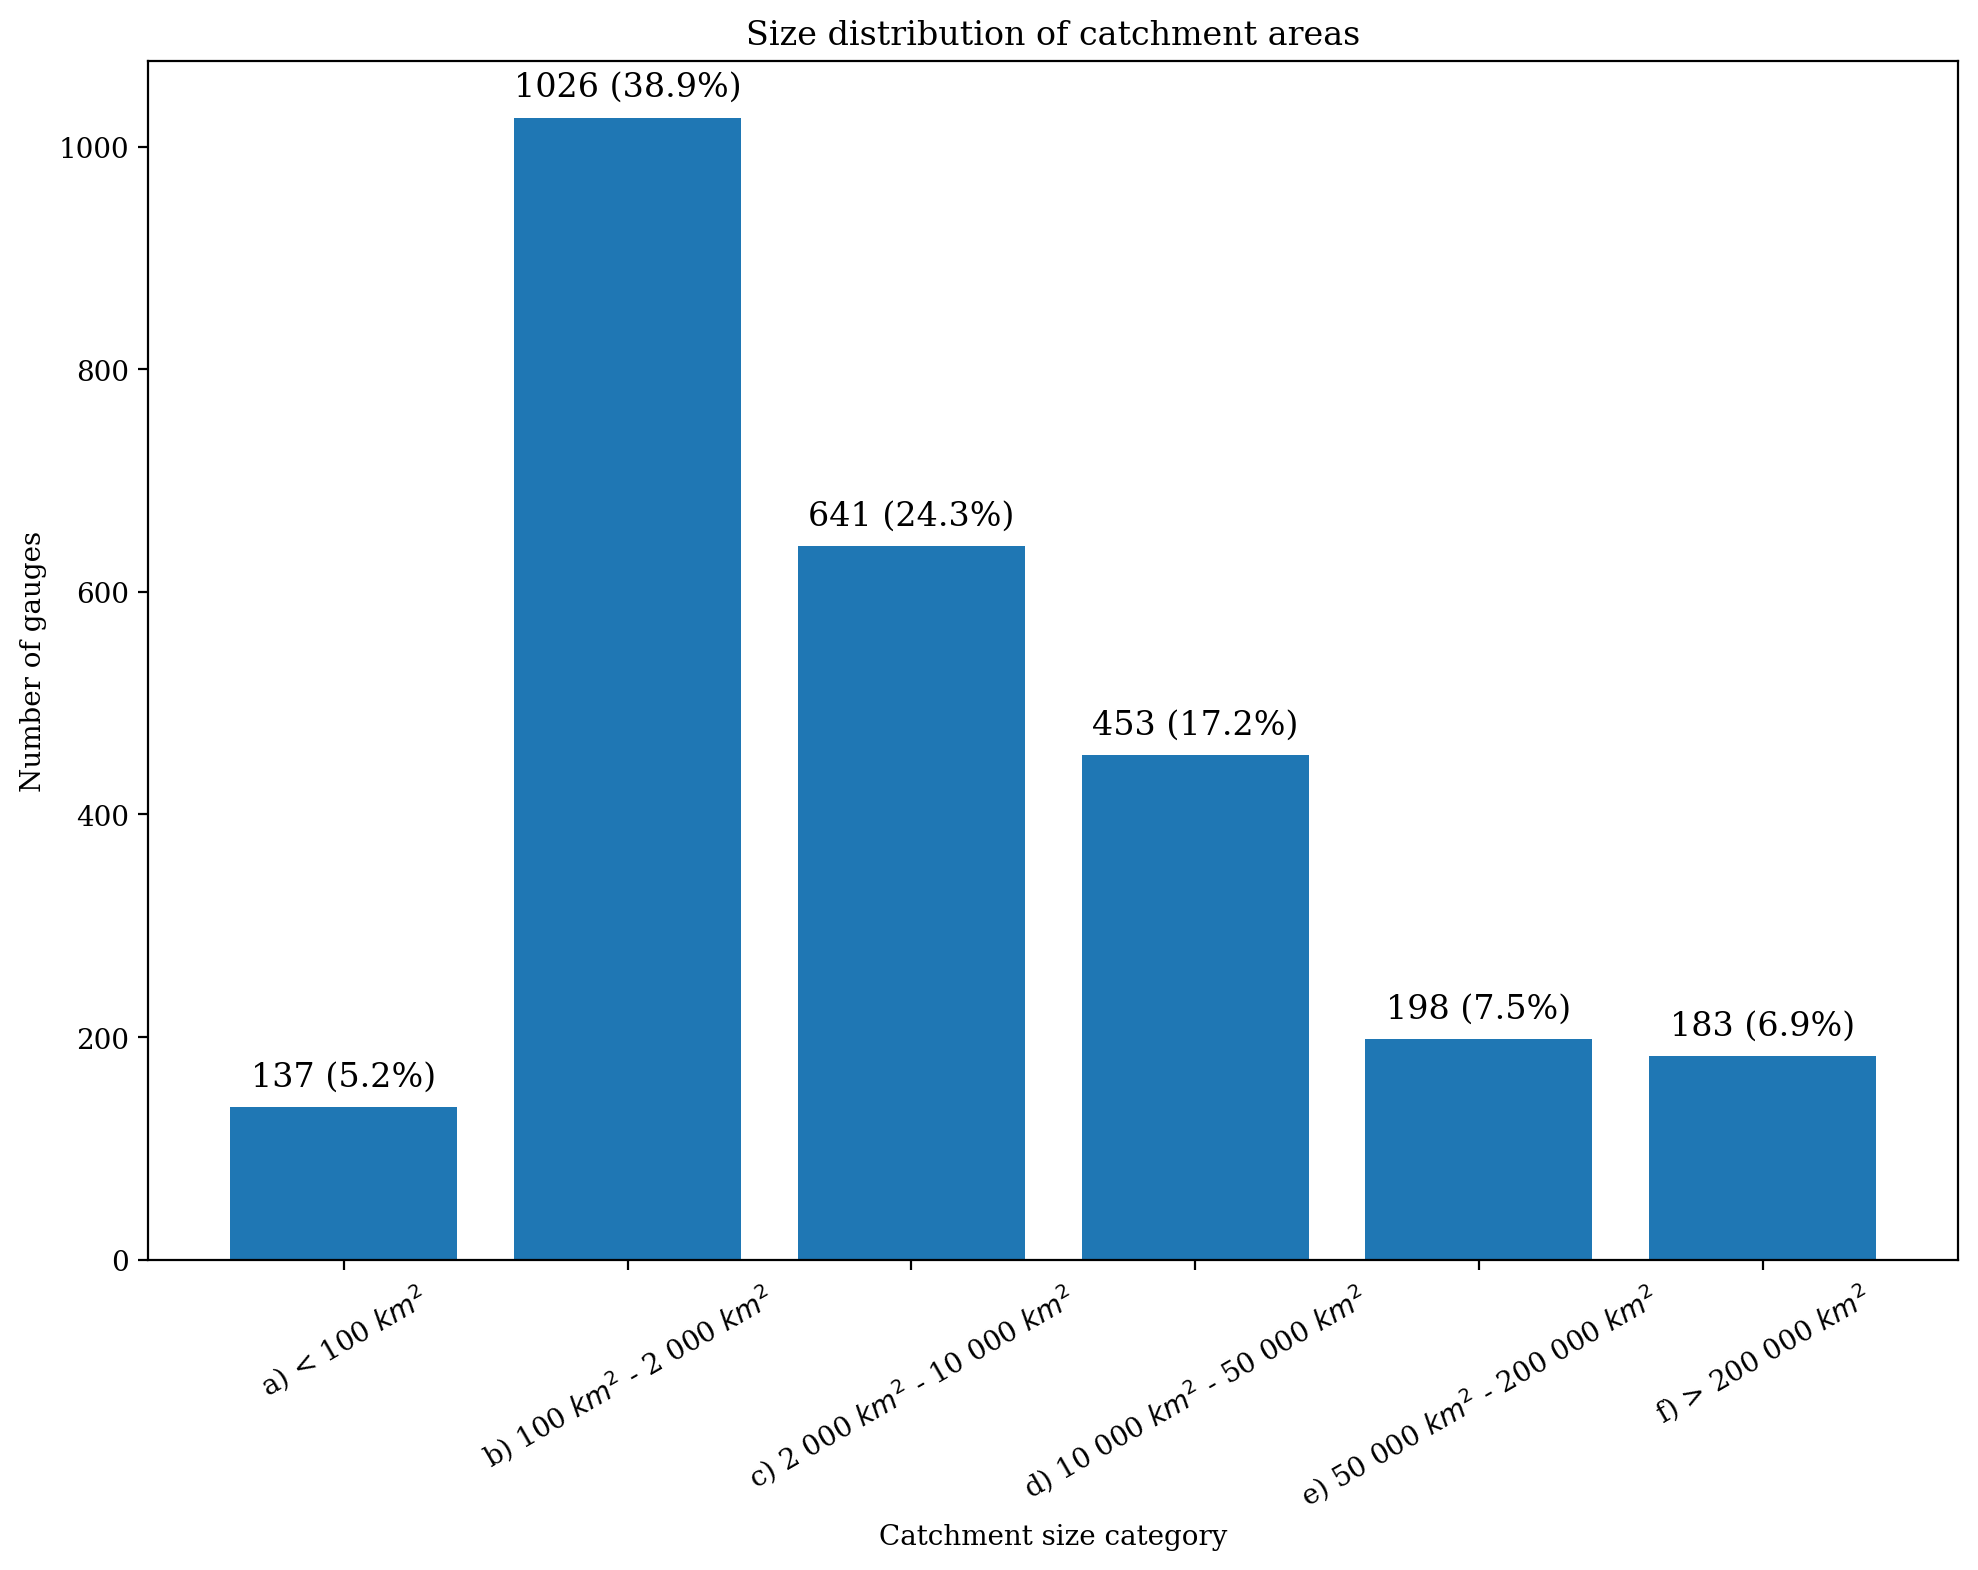

In [96]:
# plot size distribution of catchments
counts = ws["size"].value_counts(sort=False)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(counts.index.astype(str), counts.values, color="C0")
ax.set_xlabel("Catchment size category")
ax.set_ylabel("Number of gauges")
ax.set_title("Size distribution of catchment areas")
ax.tick_params(axis="x", rotation=30)

total = counts.sum()
for rect, cnt in zip(bars, counts.values, strict=False):
    pct = cnt / total * 100
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + total * 0.005,
        f"{cnt} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
    )
fig.savefig("../paper/images/Size_distribution.png", dpi=300)
plt.tight_layout()
plt.show()

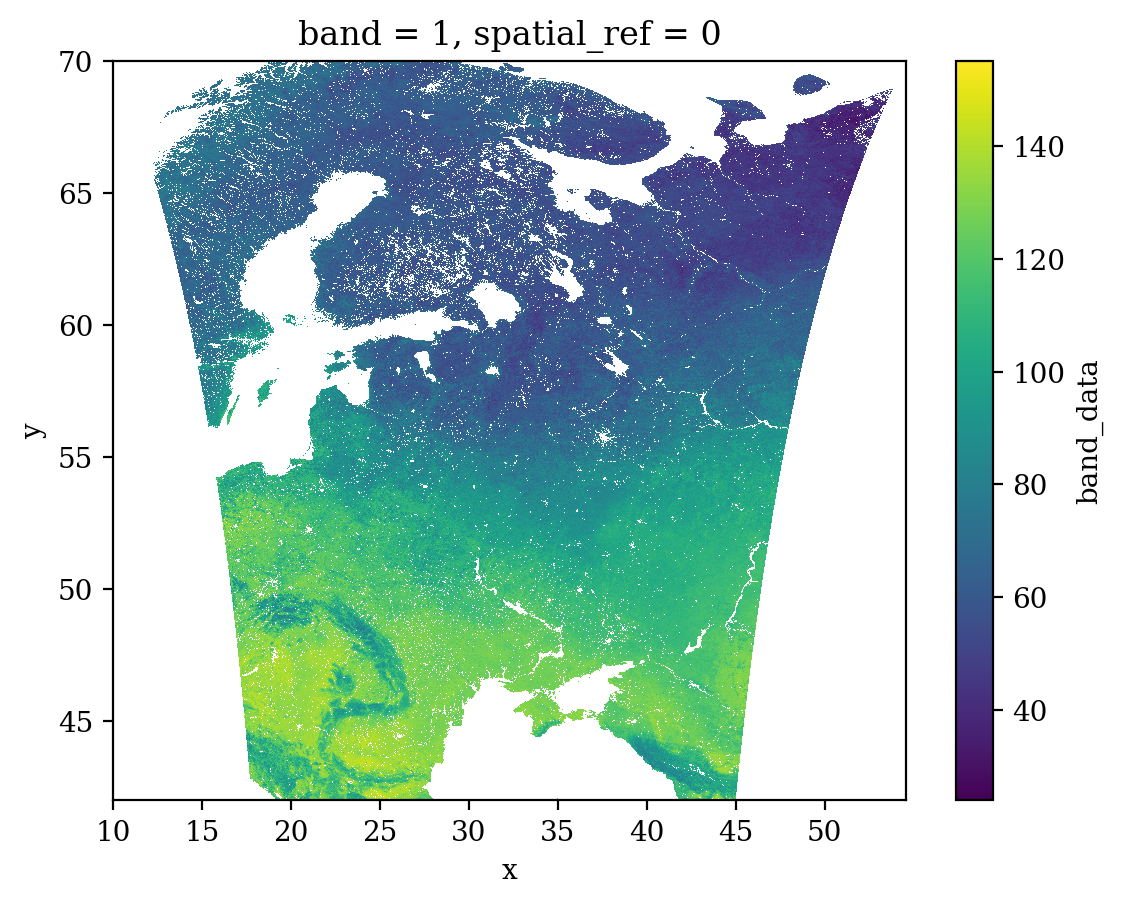

In [104]:
import xarray as xr

with xr.open_dataset(
    "/home/dmbrmv/Development/camels_ru/data/SpatialData/SoilGrids/bdod/bdod_0-5cm_mean.tif"
) as soil:
    pass

soil["band_data"].plot()

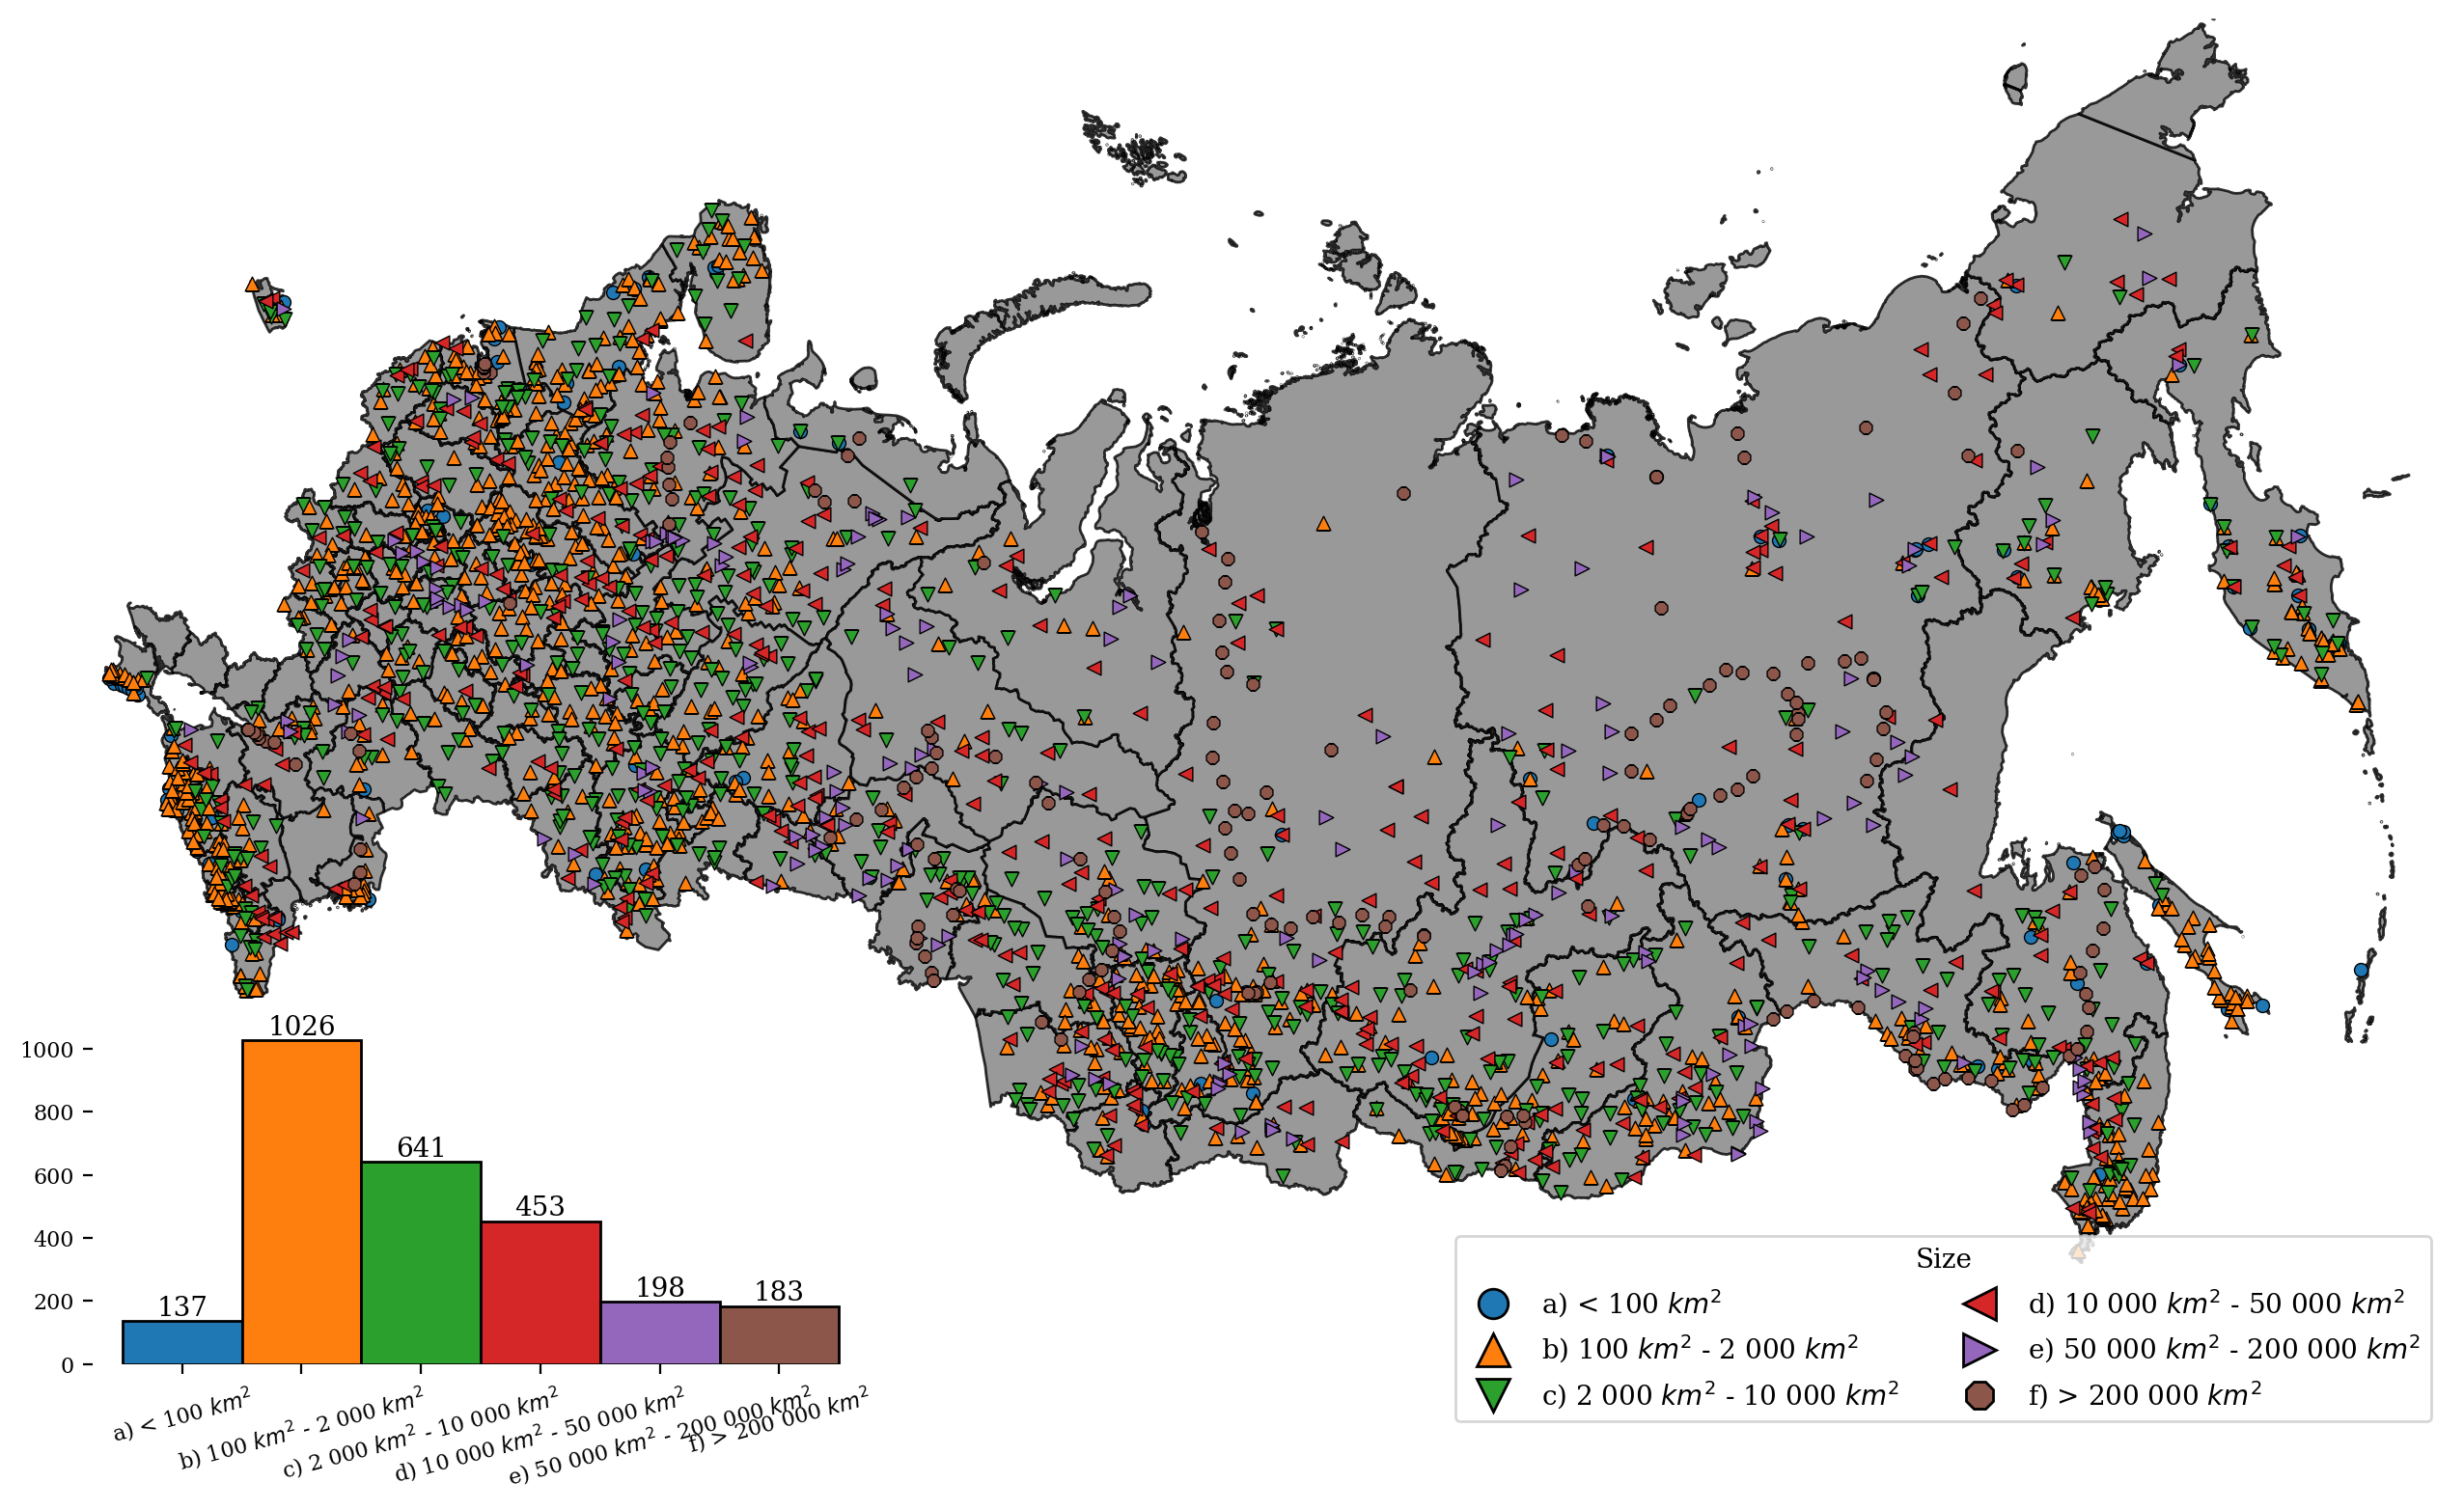

In [106]:
gauge["Size"] = ws["size"]

markers = ["o", "^", "v", "<", ">", "8", "*", "s", "D", "P", "X", "h", "H", "p", "d"]
colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
]
marker_corrections = {
    "o": 1.00,  # circle - baseline
    "^": 1.15,  # triangle up - enlarged
    "v": 1.15,  # triangle down - enlarged
    "<": 1.15,  # triangle left - enlarged
    ">": 1.15,  # triangle right - enlarged
    "d": 1.00,  # thin diamond
    "p": 1.05,  # pentagon - slightly enlarged
    "h": 1.05,  # hexagon1 - slightly enlarged
    "H": 0.95,  # hexagon2 - slightly reduced
    "8": 1.00,  # octagon
    "X": 1.10,  # x filled - enlarged
    "*": 1.20,  # star - much enlarged
    "D": 0.85,  # diamond - reduced
    "P": 0.90,  # plus filled - reduced
    "s": 0.80,  # square - significantly reduced (was the problem!)
}
gauges_fig_improved = russia_plots(
    gdf_to_plot=gauge,
    basemap_data=basemap_data,
    distinction_col="Size",
    markers_list=markers,
    color_list=colors,
    figsize=(15, 8),
    marker_size_corrections=marker_corrections,
    just_points=True,
    legend_cols=2,
    base_marker_size=25,
    base_linewidth=0.5,
    with_histogram=True,
)
gauges_fig_improved.savefig("../paper/images/Size_distribution_map.png", dpi=300)

### Histogram Color Alignment

The histogram bars now use the same colors as the map markers for visual consistency.

### Perform clustering based on static attributes

In [ ]:
# remove 'ws_area' from the selected features (safe if not present)
cluster_features = [f for f in cluster_features if f != "ws_area"]
cluster_features


['inu_pc_ult',
 'lka_pc_use',
 'lkv_mc_usu',
 'gwt_cm_sav',
 'tmp_dc_s01',
 'pre_mm_s01',
 'pre_mm_s07',
 'cmi_ix_s03',
 'snw_pc_s01',
 'snw_pc_s06',
 'snw_pc_s07',
 'snw_pc_s08',
 'glc_pc_s02',
 'glc_pc_s04',
 'glc_pc_s06',
 'glc_pc_s09',
 'glc_pc_s13',
 'glc_pc_s15',
 'glc_pc_s16',
 'glc_pc_s17',
 'glc_pc_s18',
 'for_pc_sse',
 'cly_pc_sav',
 'slt_pc_sav',
 'hft_ix_s93',
 'ws_area',
 'lon']

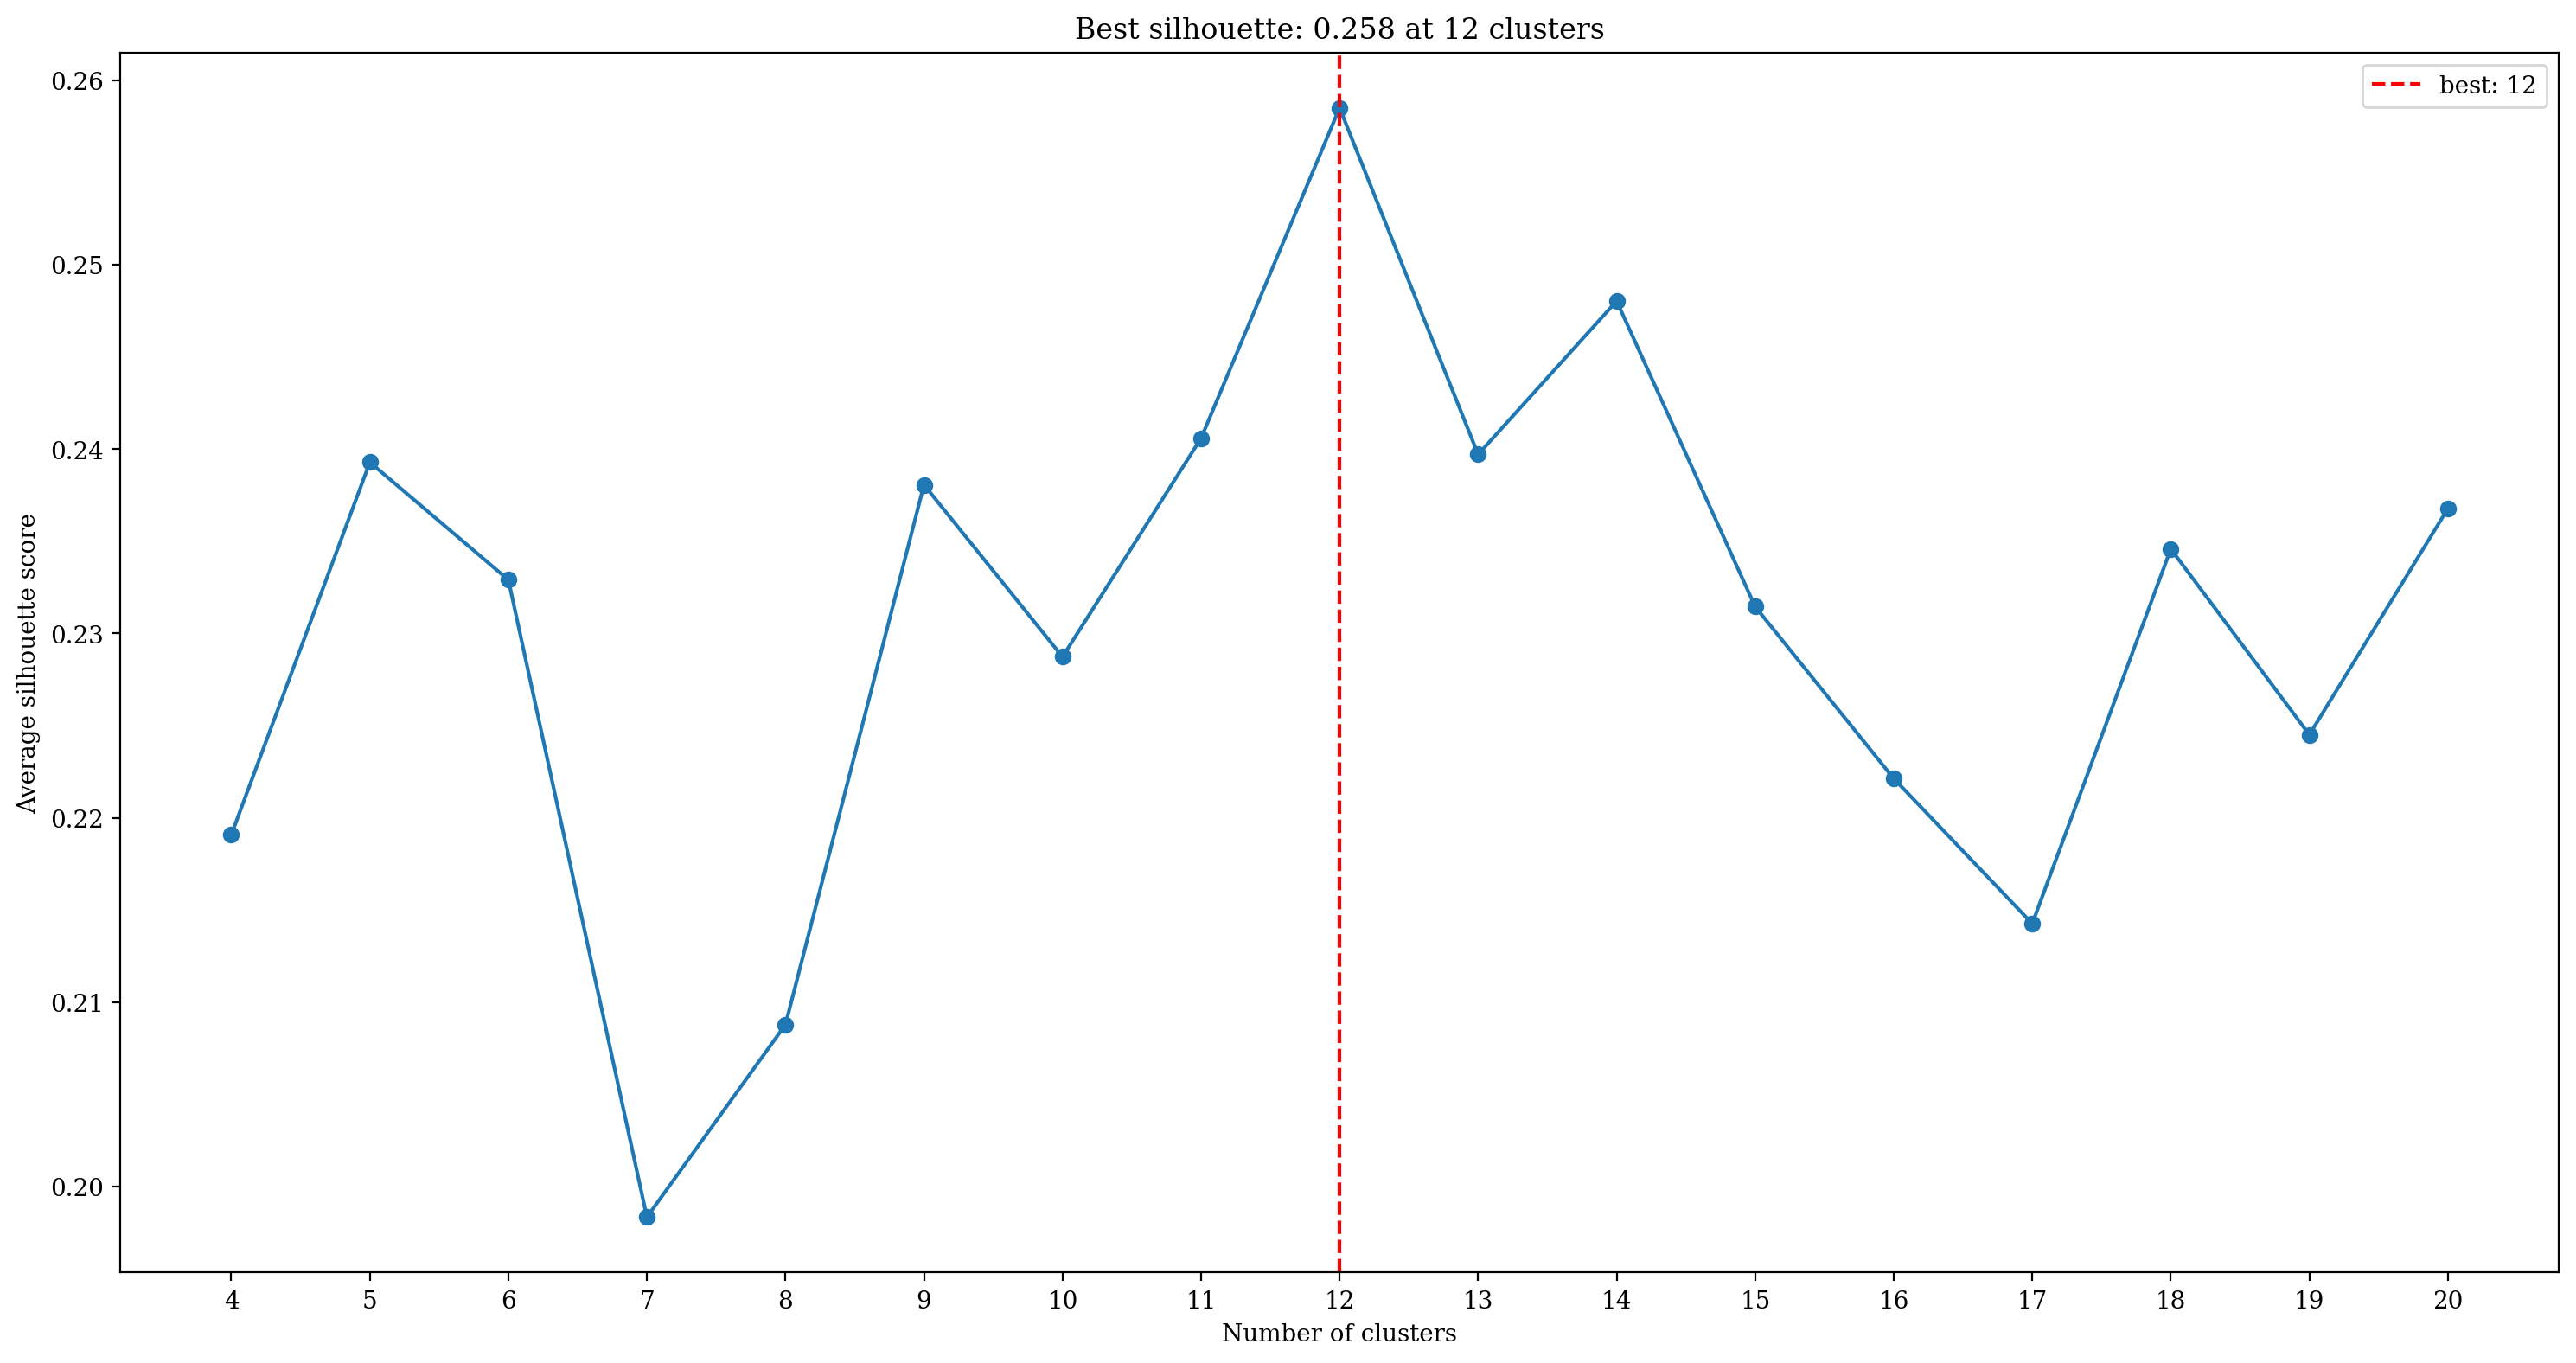

In [87]:
static_data = pd.read_csv(
    "../data/attributes/hydro_atlas_cis_camels.csv", index_col="gauge_id", dtype={"gauge_id": str}
)
cluster_features = select_uncorrelated_features(static_data, threshold=0.75, min_valid_fraction=0.8)
cluster_features = [f for f in cluster_features if f != "ws_area"]
cluster_features = [
    "for_pc_sse",
    "crp_pc_sse",
    "inu_pc_ult",
    "ire_pc_sse",
    "lka_pc_use",
    "prm_pc_sse",
    "pst_pc_sse",
    "cly_pc_sav",
    "slt_pc_sav",
    "snd_pc_sav",
    "kar_pc_sse",
    "urb_pc_sse",
    "gwt_cm_sav",
    "lkv_mc_usu",
    "rev_mc_usu",
    "ws_area",
    "ele_mt_sav",
]
static_data = static_data.loc[gauge.index, cluster_features]
static_norm = (static_data - static_data.mean()) / static_data.std()
static_norm = static_norm.dropna(axis=1)
raw_features = static_norm.values

plot_silhouette_range(raw_features, min_clusters=4, max_clusters=20, random_state=42);


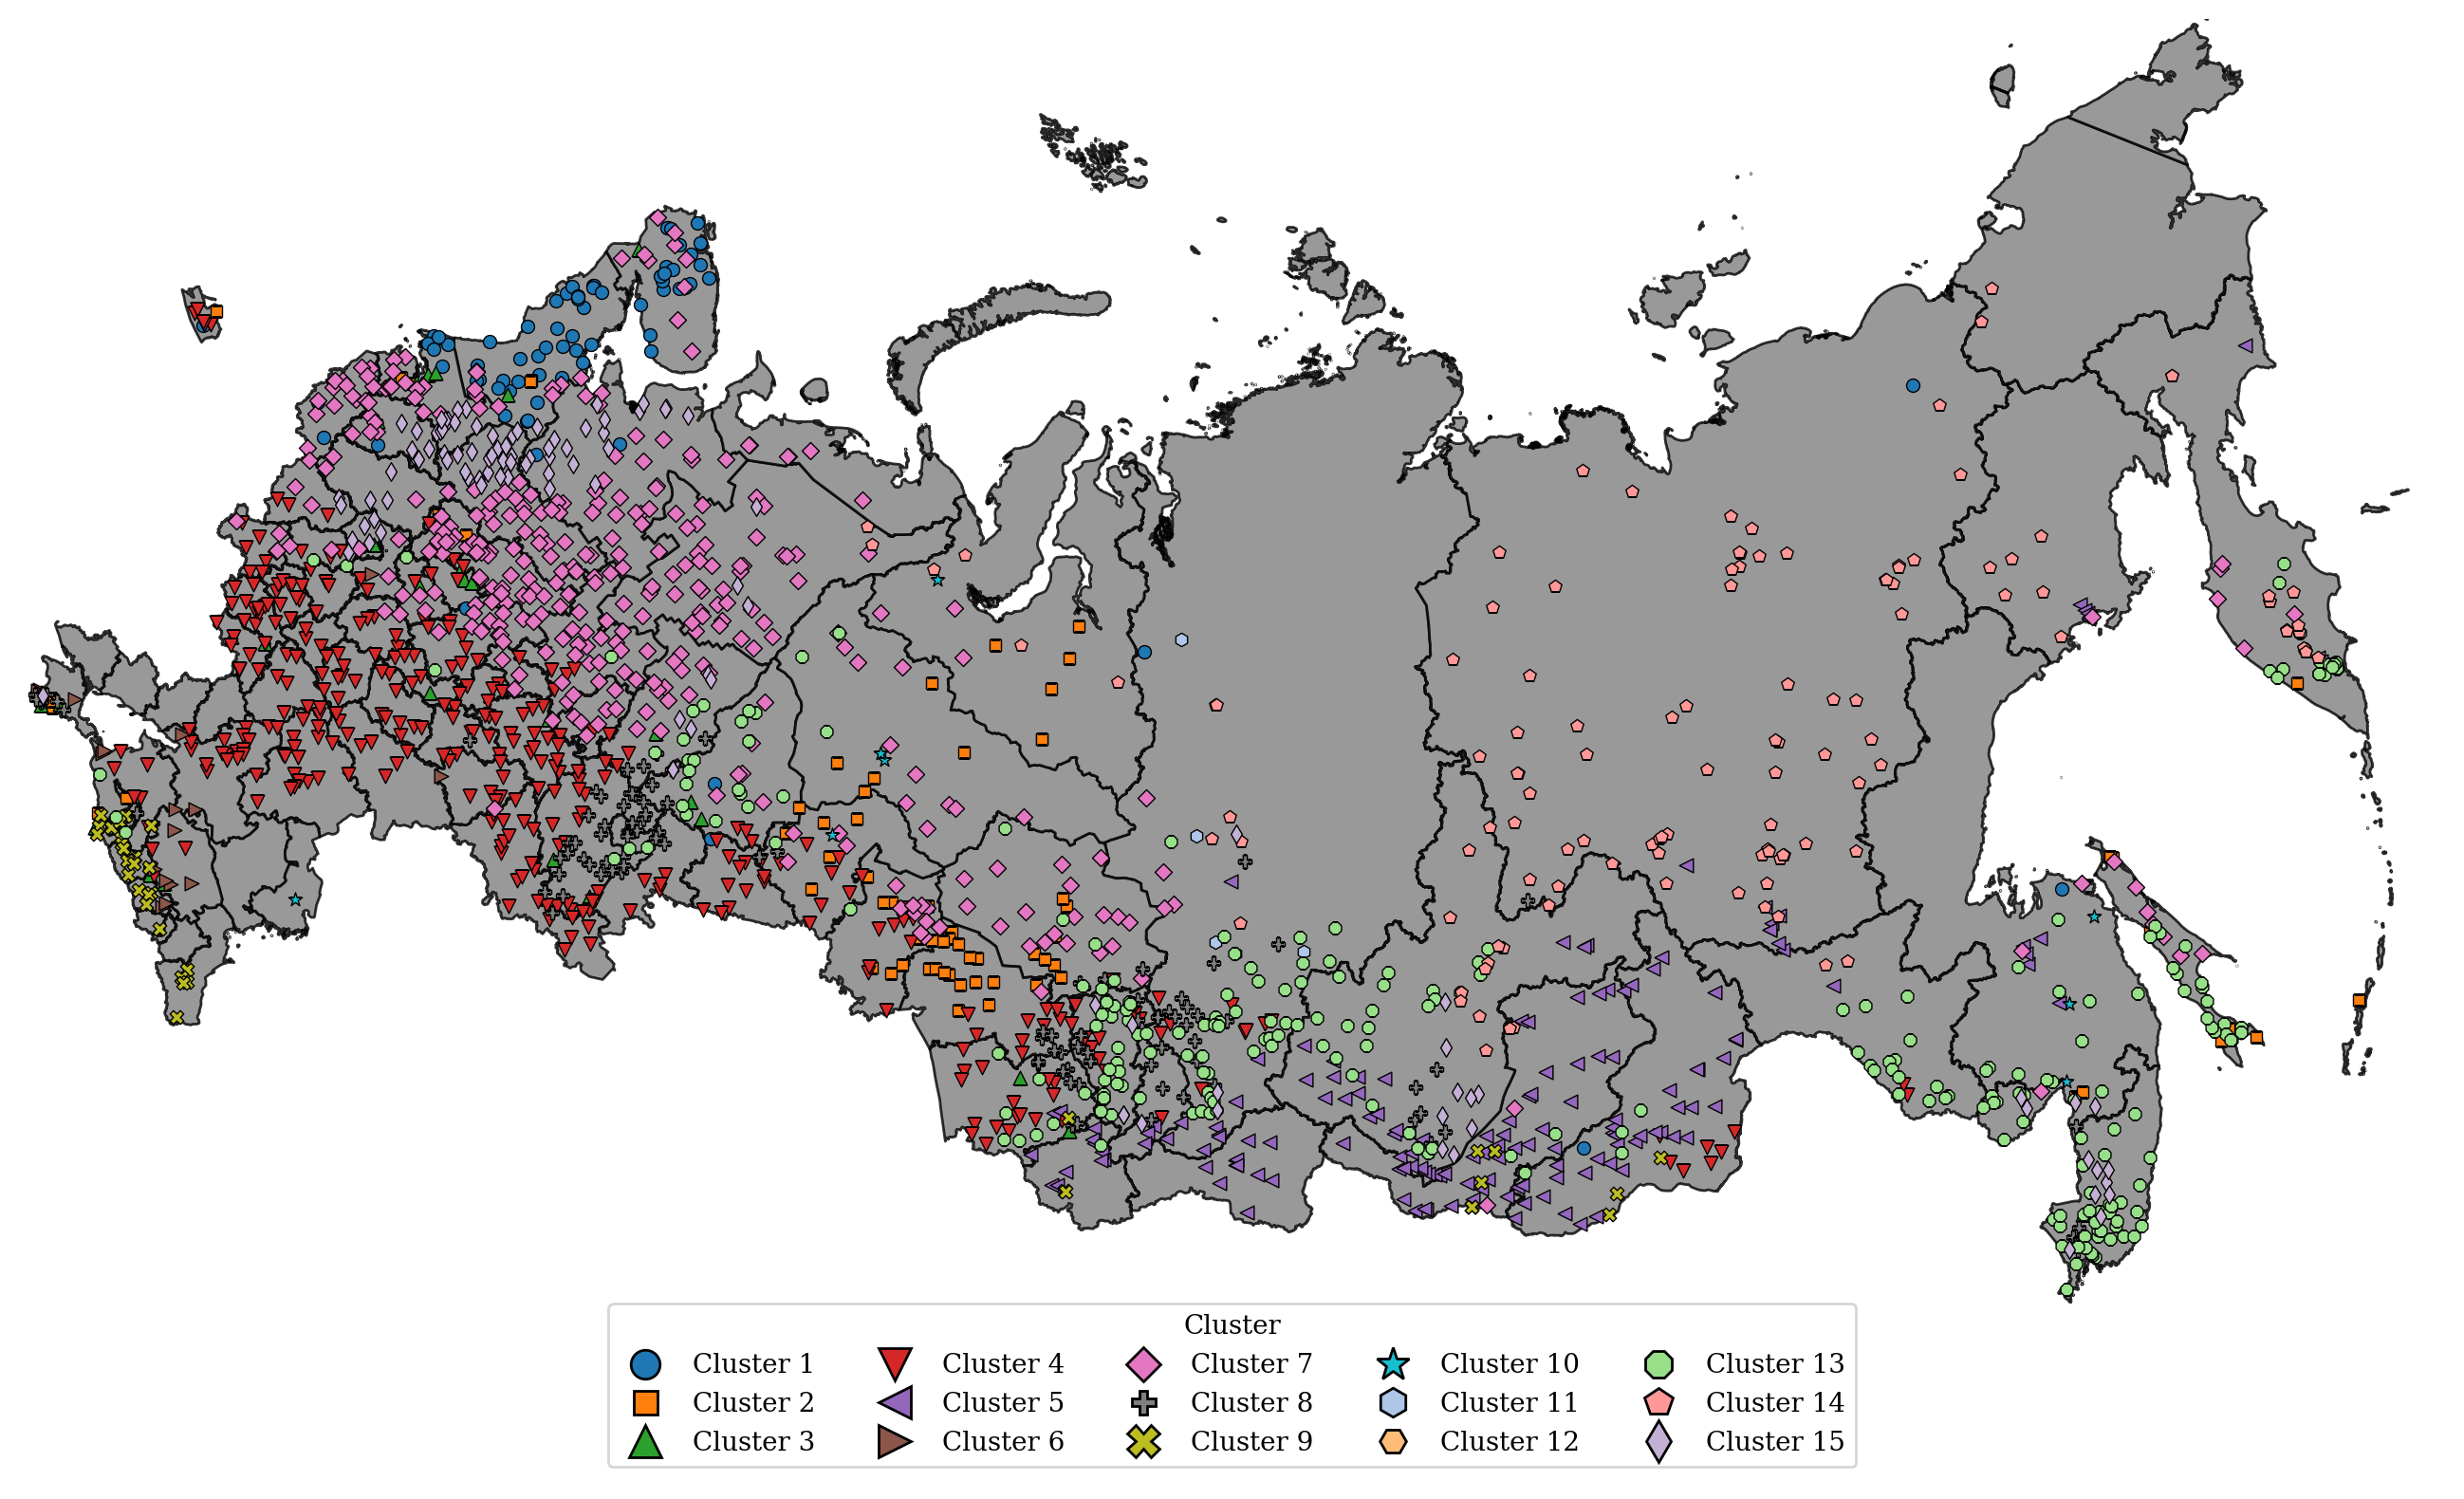

In [89]:
number_of_clusters = 15

cluster_alg = KMeans(n_clusters=number_of_clusters, random_state=42, init="k-means++")


y_hat = cluster_alg.fit_predict(raw_features)
static_norm["ResClust"] = [i + 1 for i in y_hat]
gauge["ResClust"] = np.nan
static_data["ResClust"] = np.nan

gauge = gauge.combine_first(static_norm).dropna()
static_data = static_data.combine_first(static_norm).dropna()
gauge["Cluster"] = [f"Cluster {int(i)}" for i in gauge["ResClust"]]

markers = ["o", "s", "^", "v", "<", ">", "D", "P", "X", "*", "h", "H", "8", "p", "d"]
colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
]
marker_corrections = {
    "o": 1.00,  # circle - baseline
    "^": 1.15,  # triangle up - enlarged
    "v": 1.15,  # triangle down - enlarged
    "<": 1.15,  # triangle left - enlarged
    ">": 1.15,  # triangle right - enlarged
    "d": 1.00,  # thin diamond
    "p": 1.05,  # pentagon - slightly enlarged
    "h": 1.05,  # hexagon1 - slightly enlarged
    "H": 0.95,  # hexagon2 - slightly reduced
    "8": 1.00,  # octagon
    "X": 1.10,  # x filled - enlarged
    "*": 1.20,  # star - much enlarged
    "D": 0.85,  # diamond - reduced
    "P": 0.90,  # plus filled - reduced
    "s": 0.80,  # square - significantly reduced (was the problem!)
}
gauges_fig_improved = russia_plots(
    gdf_to_plot=gauge,
    basemap_data=basemap_data,
    distinction_col="Cluster",
    markers_list=markers,
    color_list=colors,
    marker_size_corrections=marker_corrections,
    figsize=(15, 8),
    just_points=True,
    legend_cols=5,
    base_marker_size=25,
    base_linewidth=0.5,
)


#### Apply size-corrected markers to clustering plot

In [251]:
gauges_fig_improved.savefig("../paper/images/Clusters_map.png", dpi=300)

In [ ]:
import matplotlib.colors as mcolors
import plotly.express as px

cluster_stats = []
for i, group_id in static_norm.groupby("ResClust").groups.items():
    g_clust = static_norm.loc[group_id, cluster_features].mean().to_frame().T
    g_clust.index = [i]
    g_clust.index.name = "Cluster"
    cluster_stats.append(g_clust)
cluster_stats = pd.concat(cluster_stats)
cluster_stats = cluster_stats.reset_index()

cluster_stats

,Cluster,for_pc_sse,crp_pc_sse,inu_pc_ult,ire_pc_sse,lka_pc_use,prm_pc_sse,pst_pc_sse,cly_pc_sav,slt_pc_sav,snd_pc_sav,kar_pc_sse,urb_pc_sse,gwt_cm_sav,lkv_mc_usu,rev_mc_usu,ws_area,ele_mt_sav
0,1,0.147774,-0.577674,1.013969,-0.190814,3.460922,-0.375845,-0.616516,-1.269068,-1.793688,1.796847,-0.375492,-0.124432,-0.157397,-0.039939,-0.037563,-0.172006,-0.597273
1,2,-0.055827,-0.390134,3.802699,-0.137253,0.449567,-0.310328,0.101151,-0.046204,-0.537399,0.365261,-0.268804,-0.183250,-0.644724,-0.063884,-0.044920,-0.117239,-0.649654
2,3,-0.735816,0.752240,0.087173,0.274609,0.130196,-0.525315,0.598437,0.505319,-0.124720,-0.183145,0.334428,5.899039,0.143094,-0.006269,0.357679,-0.176137,-0.258600
3,4,-1.402620,1.631837,-0.261332,0.146006,-0.145764,-0.518334,1.237884,1.065754,0.596413,-0.935682,-0.419493,0.161516,-0.060111,-0.065211,-0.031828,-0.047131,-0.432176
4,5,0.258487,-0.646492,-0.333552,-0.213049,-0.241607,1.387630,-0.540151,-0.888540,-0.518069,0.797905,-0.269514,-0.219551,1.078837,-0.050978,-0.049535,-0.081272,1.824492
5,6,-1.303707,1.570254,0.024494,8.130804,-0.133352,-0.487925,1.142870,2.324781,-0.079490,-1.158646,0.813822,1.500224,1.103577,-0.067212,-0.036874,-0.152661,0.103872
6,7,0.540645,-0.389162,-0.174593,-0.153095,-0.169881,-0.408244,-0.424178,-0.673739,-0.737078,0.822147,-0.440760,-0.201377,-0.652799,-0.065025,-0.044202,-0.114268,-0.630386
7,8,0.320386,-0.043910,-0.272109,-0.126622,-0.264239,-0.389435,0.058292,0.862305,1.200076,-1.205651,1.170532,-0.117196,-0.124483,-0.059717,-0.047038,-0.142952,0.049779
8,9,-0.821793,-0.446919,-0.033794,-0.157938,-0.302064,0.189923,2.109040,0.819139,-0.085770,-0.371372,0.298444,-0.104703,3.360110,-0.000026,-0.049633,0.137839,3.296704
9,10,-0.600655,0.132881,0.213369,1.643404,0.245546,-0.202800,1.086184,0.213253,0.367788,-0.403132,-0.347070,0.070390,-0.494329,0.018789,0.405730,10.931493,-0.111860


In [ ]:
polar = pd.melt(cluster_stats, id_vars=["Cluster"])
# polar["variable"] = [russian_names[i] for i in polar["variable"]]

cmap_name: str = "turbo"
cmap = plt.get_cmap(cmap_name, number_of_clusters)
color_list = [mcolors.rgb2hex(cmap(i)) for i in range(cmap.N)]

fig_polar = px.line_polar(
    polar,
    r="value",
    theta="variable",
    color="Cluster",
    color_discrete_sequence=color_list,
    template="seaborn",
    height=900,
    width=1500,
)
fig_polar.update_layout(
    polar={
        "radialaxis": {"showticklabels": False, "ticks": ""},
        "angularaxis": {"showticklabels": True, "tickangle": 0},
    },
    legend_title_text="Clusters",
    # legend_title_text=None,
    legend={
        "orientation": "h",
        "yanchor": "top",
        "y": -0.1,
        "xanchor": "center",
        "x": 0.5,
        "bgcolor": None,
        "bordercolor": "Black",
        "borderwidth": 0,
    },
)
# fig_polar.write_image("./images/cluster_importance_tft.png")
plt.tight_layout()
fig_polar


<Figure size 640x480 with 0 Axes>

### Perform clustering based on hydrological attributes